#Code for training a CNN (resnet) to classify fruits and vegetables

In [1]:
#Import required packages
import kagglehub
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchprofile import profile_macs
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets
from collections import defaultdict
from torch.utils.data import Dataset
import re
import random

import json

In [2]:
#Hyperparmeters
batch_size = 10
learning_rate = 1e-4
num_epochs = 10
patience = 3 #Number of epochs to wait for improvement before stopping training

In [3]:
#Helper functions (from assignment 1)
def get_model_macs(model, inputs) -> int:
    return profile_macs(model, inputs)

def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
    """
    calculate the total number of parameters of model
    :param count_nonzero_only: only count nonzero weights
    """
    num_counted_elements = 0
    for param in model.parameters():
        if count_nonzero_only:
            num_counted_elements += param.count_nonzero()
        else:
            num_counted_elements += param.numel()
    return num_counted_elements

def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    """
    calculate the model size in bits
    :param data_width: #bits per element
    :param count_nonzero_only: only count nonzero weights
    """
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

In [4]:
# Download latest version
#Food-Ingredient-Dataset-51
#path = kagglehub.dataset_download("sunnyagarwal427444/food-ingredient-dataset-51")

#Fruits-360 dataset
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
    print(root)
    break

Path to dataset files: /home/edhaas/.cache/kagglehub/datasets/moltean/fruits/versions/87
/home/edhaas/.cache/kagglehub/datasets/moltean/fruits/versions/87


In [5]:
class MappedSubset(Dataset):
    def __init__(self, base_ds, keep_list, label2id, transform=None):
        self.base_ds = base_ds
        self.keep_list = keep_list  # list of (base_index, canon_label)
        self.label2id = label2id
        self.transform = transform

        # --- mimic ImageFolder API ---
        self.classes = [None] * len(label2id)
        for name, idx in label2id.items():
            self.classes[idx] = name
        self.class_to_idx = dict(label2id)

    def __len__(self):
        return len(self.keep_list)

    def __getitem__(self, idx):
        base_i, canon_label = self.keep_list[idx]
        img, _ = self.base_ds[base_i]
        if self.transform:
            img = self.transform(img)
        y = self.label2id[canon_label]
        return img, y

In [6]:
train_raw = datasets.ImageFolder(root=path+"/fruits-360_original-size/fruits-360-original-size/Training/")
val_raw   = datasets.ImageFolder(root=path+"/fruits-360_original-size/fruits-360-original-size/Validation/")

def canonical(label: str) -> str:
    s = label.strip().lower().replace("_", " ")
    s = re.sub(r"\s+\d+$", "", s)  # remove trailing numbers like "apple 10"

    if s.startswith("tomato"):
        return "tomato"
    if s.startswith("apple"):
        return "apple"
    if s.startswith("banana"):
        return "banana"
    if s.startswith("pear"):
        return "pear"
    if s.startswith("cucumber"):
        return "cucumber"
    if s.startswith("orange"):
        return "orange"
    if s.startswith("onion"):
        return "onion"
    # if s.startswith("pepper"): #I think it is too diverse
    #     return "pepper"
    if s.startswith("cabbage"):
        return "cabbage"
    if s.startswith("blackberry"):
        return "blackberry"
    if s.startswith("avocado"):
        return "avocado"
    if s.startswith("raspberry"):
        return "raspberry"
    if s.startswith("strawberry"):
        return "strawberry"
    if s.startswith("carrot"):
        return "carrot"
    return s

KEEP = {
    "apple", "banana", "orange", "pear",
    "tomato", "cucumber", "onion",
    "cabbage", "avocado", "raspberry", "blackberry",
    "strawberry", "carrot"
}

SEED = 42
MAX_PER_CANON = 500
MAX_VAL_PER_CANON = 200
random.seed(SEED)

idx_to_canon_train = {idx: canonical(name) for name, idx in train_raw.class_to_idx.items()}
idx_to_canon_val   = {idx: canonical(name) for name, idx in val_raw.class_to_idx.items()}

all_train = defaultdict(list)
for i, (_, orig_idx) in enumerate(train_raw.samples):
    canon = idx_to_canon_train[orig_idx]
    if canon in KEEP:
        all_train[canon].append(i)

train_keep = []
for c, idxs in all_train.items():
    random.shuffle(idxs)
    for i in idxs[:MAX_PER_CANON]:
        train_keep.append((i, c))
random.shuffle(train_keep)

all_val = defaultdict(list)
for i, (_, orig_idx) in enumerate(val_raw.samples):
    canon = idx_to_canon_val[orig_idx]
    if canon in KEEP:
        all_val[canon].append(i)

val_keep = []
for c, idxs in all_val.items():
    random.shuffle(idxs)
    for i in idxs[:MAX_VAL_PER_CANON]:
        val_keep.append((i, c))
random.shuffle(val_keep)

canon_classes = sorted(KEEP)
label2id = {name: j for j, name in enumerate(canon_classes)}
id2label = {str(j): name for name, j in label2id.items()}

with open("../JSON/id2label_produce_newdata.json", "w") as f:
    json.dump(id2label, f, indent=2)
with open("../JSON/label2id_produce_newdata.json", "w") as f:
    json.dump(label2id, f, indent=2)

In [7]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

#Apply transform to the dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    #transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),   # zoom/crop variation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2))],
        p=0.9
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

#save mean and std before normalization
norm_stats = {
    "mean": mean,
    "std": std
}
with open("../JSON/norm_stats_produce_newdata.json", "w") as f:
    json.dump(norm_stats, f)

train_dataset = MappedSubset(train_raw, train_keep, label2id, transform=train_transform)  # <- use your train transform
val_dataset   = MappedSubset(val_raw,   val_keep,   label2id, transform=val_transform)    # <- val transform

#Create dataloaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

print("New #classes:", len(train_dataset.classes))
print("Class names:", train_dataset.classes)
print("Train samples:", len(train_dataset), "Val samples:", len(val_dataset))

New #classes: 13
Class names: ['apple', 'avocado', 'banana', 'blackberry', 'cabbage', 'carrot', 'cucumber', 'onion', 'orange', 'pear', 'raspberry', 'strawberry', 'tomato']
Train samples: 5619 Val samples: 2311


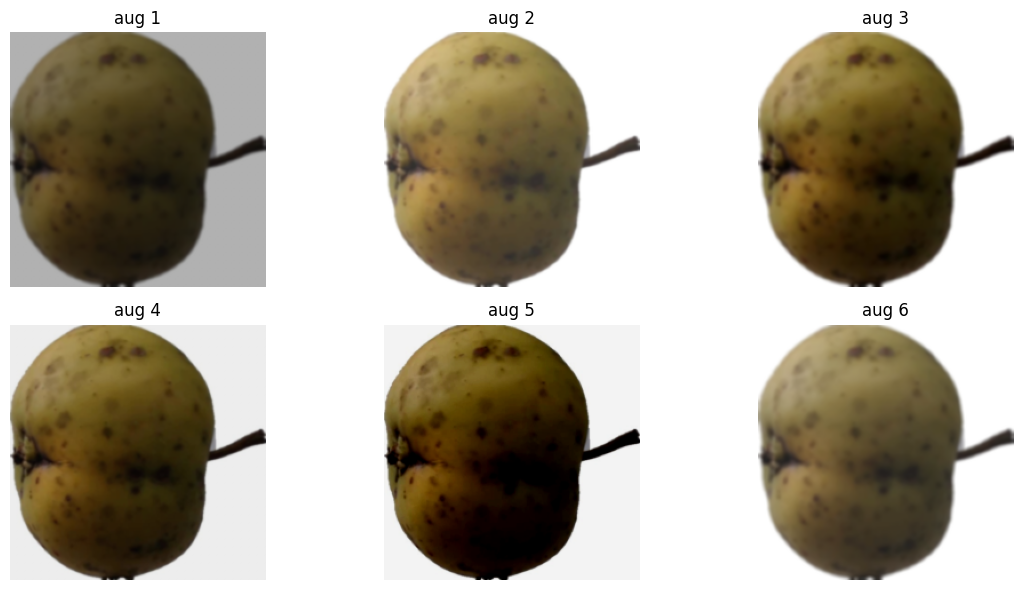

Label idx: 8
Label name: Apple 19


In [8]:
pil_img, label_idx = train_raw[3000]

# Use the same mean/std you trained with
MEAN = torch.tensor(mean).view(3,1,1)
STD  = torch.tensor(std).view(3,1,1)

def show_tensor_img(t, title=None):
    t = t.detach().cpu()
    t = (t * STD) + MEAN
    t = t.clamp(0, 1)
    img = t.permute(1,2,0).numpy()
    plt.imshow(img)
    if title: plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12, 6))
for i in range(6):
    aug = train_transform(pil_img)  #transformed data
    plt.subplot(2, 3, i+1)
    show_tensor_img(aug, title=f"aug {i+1}")

plt.tight_layout()
plt.show()

print("Label idx:", label_idx)
print("Label name:", train_raw.classes[label_idx])

In [9]:
#Load Resnet model
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes)) #make the last fc layer output the correct number of classes

#Setup GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/home/edhaas/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/edhaas/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Train the model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#setup early exiting
best_loss = float('inf')
epochs_without_improvement = 0

#training loop
for epoch in range(num_epochs):
    print("Staring epoch", epoch)
    model.train() #enable training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images) #compute predictions
        loss = criterion(outputs, labels) #compute loss
        loss.backward() #backward pass
        optimizer.step() #update model weights

        #track training loss
        running_loss += loss.item()

        #track training accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    #calculate epoch loss
    epoch_loss = running_loss / len(train_loader)

    #calculate epoch accuracy
    epoch_acc = 100 * correct / total

    print("Epoch: ", epoch, "/", num_epochs, " Loss: ", epoch_loss, " Accuracy:", epoch_acc)
    
    #check if loss is still improving
    if epoch_loss < best_loss: #loss improved
        best_loss = epoch_loss
        epochs_without_improvement = 0
        
    else: #loss did not improve
        epochs_without_improvement += 1
        
    #stop training if loss is not improving
    if epochs_without_improvement >= patience:
        print("Early stopping triggered")
        break

In [ ]:
#Save trained model
PATH = './produce_net_newdata.pth'
torch.save(model, PATH)

In [ ]:
#Load model
PATH = './produce_net_newdata.pth'
model = torch.load(PATH, weights_only=False)

In [ ]:
#Find network validation accuracy
correct = 0
total = 0

model.eval() #enable evaluation mode

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images) #get predicted classes
        
        #compare predicted and actual labels
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        #get network accuracy
        val_acc = 100 * (correct / total)
        
    print(f"Validation accuracy of the network: {val_acc:.2f} %")

In [ ]:
#Get model information
model_size = get_model_size(model)
print(f"Model Size {model_size/MiB:.2f} MiB")

num_parameters = get_num_parameters(model)
print(f"Parameter Count (M) {num_parameters/1e6:.2f}")

dummy_input = torch.randn(1, 3, 224, 224).to(device)
macs = get_model_macs(model, dummy_input)
print(f"MACS (B) {macs/1e9:.2f}")